# 🧮 Customer Segmentation (Clustering) 

In this notebook, we will:
1. Preprocess our RFM features (Log Transformation & Scaling).
2. Apply **K-Means** clustering and find the optimal number of clusters using both **Inertia (Elbow Method)** and the **Silhouette Score**.
3. Apply **DBSCAN** clustering to identify core groups and outliers.
4. Evaluate the clusters and provide **Business Interpretations**.

In [1]:
# Loading libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import os
import pathlib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

c:\Users\SAFAE ERAJI\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data & Preprocessing
Distance-based clustering algorithms (like K-Means and DBSCAN) require data to be symmetrically distributed and on the same scale.

In [2]:
# RFM features
try:
    rfm = pd.read_csv('../data/processed/rfm_features.csv')
    print(f"Successfully loaded {len(rfm)} customers.")
except FileNotFoundError:
    print("Error: Could not find rfm_features.csv. Did you run the second notebook?")

Successfully loaded 5878 customers.


In [3]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [4]:
rfm.set_index('CustomerID', inplace=True)

In [5]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [6]:
# Log Transformation to handle right-skewness
rfm_log = np.log(rfm + 0.1) # We add a small constant (0.1) to avoid log(0) issues
rfm_log.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,5.787204,2.493205,11.258763
12347.0,0.741937,2.091864,8.501395
12348.0,4.318821,1.629241,7.610605
12349.0,2.949688,1.410987,8.395882
12350.0,5.736895,0.095310,5.812637


In [7]:
# Standardization (Mean=0, Variance=1)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)
display(rfm_scaled.head())

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,0.845198,1.250061,3.200252
12347.0,-2.256472,0.847674,1.214707
12348.0,-0.057517,0.383845,0.573261
12349.0,-0.899216,0.165022,1.138729
12350.0,0.814270,-1.154083,-0.721432


## 2. K-Means Clustering
First, we evaluate different values of `K` (number of clusters) using two mathematical metrics:
1. **Inertia (Elbow Method)**: Measures the sum of squared distances of samples to their closest cluster center (lower is better).
2. **Silhouette Score**: Measures how similar an object is to its own cluster compared to other clusters (ranges from -1 to 1; higher is better).

**🔄 K-Means Step-by-Step:**

| Step | What happens | Centroids? |
|------|--------------|-------------|
| 1 | Initialize random centroids | Random starting positions |
| 2 | Assign points to nearest centroid | Fixed (for this step) |
| 3 | **Update centroids** → move to mean of assigned points | ✅ **Updated** |
| 4 | Repeat steps 2-3 until convergence | ✅ **Updated each time** |

> **📊 Silhouette Score** A metric that measures how well-separated the clusters are in clustering algorithms

---

**Formula:** $\text{Silhouette Score} = \frac{b - a}{\max(a, b)}$

where:
- **a** = Mean distance to points in the SAME cluster (cohesion)
- **b** = Mean distance to points in the NEAREST other cluster (separation)

--- 

| Score Range | Meaning | Quality |
|-------------|---------|---------|
| **+1.0** | Perfectly separated clusters | ✅ Excellent |
| **0.0** | Overlapping clusters | ⚠️ Weak |
| **-1.0** | Wrong cluster assignment | ❌ Bad |

In [8]:
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(rfm_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, cluster_labels))

In [9]:
inertia

[8542.731429138426,
 6348.286282246354,
 4956.9938331364865,
 4170.630439627545,
 3605.353828073077,
 3244.604935367108,
 2936.004196219809,
 2721.5351840454773,
 2524.850560610026]

In [10]:
silhouette_scores

[0.43470378189679604,
 0.34356433337981346,
 0.362585521617209,
 0.3357301153194133,
 0.3359171370728467,
 0.3072246882351161,
 0.3140639107993662,
 0.28868837638082606,
 0.2819297107608708]

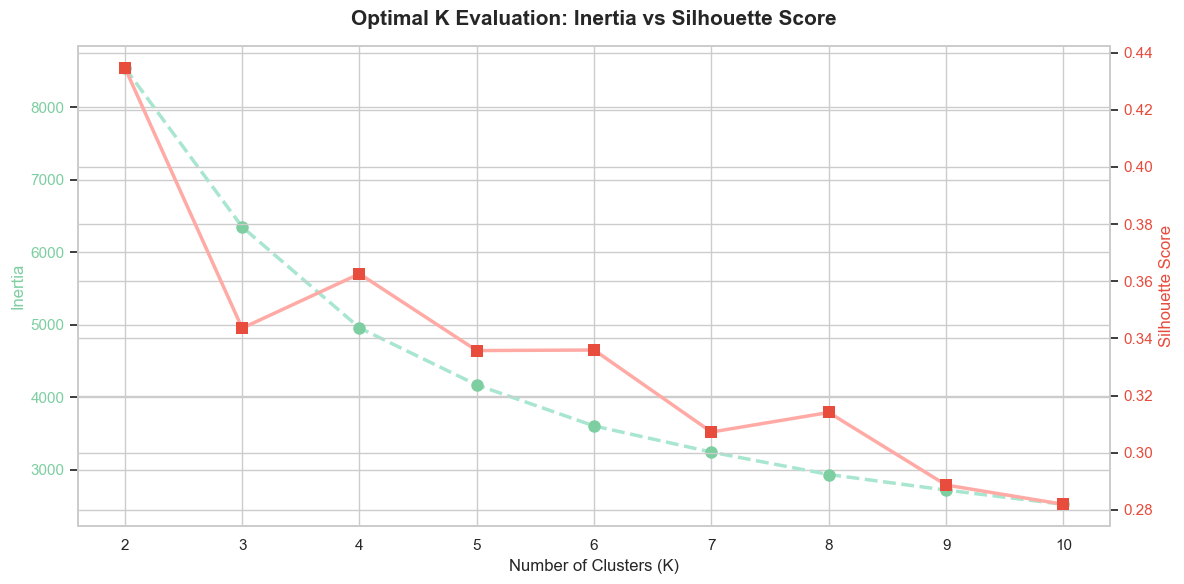

In [11]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Inertia (Elbow Method) 
color1 = '#a8e6cf' 
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia', color='#7dcea0', fontsize=12)
ax1.plot(k_range, inertia, marker='o', linestyle='--', color=color1, linewidth=2.5, 
         markersize=9, markerfacecolor='#7dcea0', markeredgewidth=0)
ax1.tick_params(axis='y', labelcolor='#7dcea0')
ax1.set_xticks(k_range)

# For Silhouette Score
ax2 = ax1.twinx() # a second y-axis that shares the same x-axis
color2 = '#ffaaa5' 
ax2.set_ylabel('Silhouette Score', color='#e74c3c', fontsize=12)  
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color=color2, linewidth=2.5,
         markersize=9, markerfacecolor='#e74c3c', markeredgewidth=0)
ax2.tick_params(axis='y', labelcolor='#e74c3c')

plt.title('Optimal K Evaluation: Inertia vs Silhouette Score', fontsize=15, fontweight='bold', pad=15)
fig.tight_layout()  
plt.show()

### Fit K-Means: Why 8 Segments?

**🧮 What the Math Says:**
The elbow at **K=4** and silhouette peak at **K=2** suggest the algorithm wants just 2–4 broad clusters.

**💼 What the Business Needs:**
2–4 segments is too blunt for real marketing. We need **6–8** to actually tell customers apart.

**The Trade-Off:**
At **K=8**, silhouette holds at ~0.30 — not negative, still coherent. We sacrifice a tiny bit of math for a huge leap in actionability: instead of just "good" vs "bad" customers, we now see Champions 🏆, Loyal Stars ⭐, Promising Newcomers 🌱, and At-Risk Big Spenders 🚨 — impossible with just 3 clusters.

In [12]:
optimal_k = 8
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['KMeans_Cluster'] = kmeans.fit_predict(rfm_scaled)

In [13]:
rfm['KMeans_Cluster']

CustomerID
12346.0    1
12347.0    4
12348.0    5
12349.0    1
12350.0    2
          ..
18283.0    3
18284.0    2
18285.0    2
18286.0    0
18287.0    1
Name: KMeans_Cluster, Length: 5878, dtype: int32

In [14]:
rfm.head()

,Recency,Frequency,Monetary,KMeans_Cluster
CustomerID,,,,
12346.0,326,12,77556.46,1
12347.0,2,8,4921.53,4
12348.0,75,5,2019.40,5
12349.0,19,4,4428.69,1
12350.0,310,1,334.40,2


In [15]:
# Evaluation with Silhouette 
sil_score = silhouette_score(rfm_scaled, rfm['KMeans_Cluster'])
print(f"Final K-Means Silhouette Score (K={optimal_k}): {sil_score:.3f}")

Final K-Means Silhouette Score (K=8): 0.314


In [16]:
if 'Segment_Name' not in rfm.columns:
    labels = [
        "Champions",
        "Loyal Customers",
        "Needs Attention",
        "At Risk",
        "Potential Loyalists",
        "Promising",
        "Recent/New Customers",
        "Hibernating / Lost"
    ]

In [17]:
ordered_clusters = rfm.groupby('KMeans_Cluster')['Monetary'].mean().sort_values(ascending=False).index
mapping = dict(zip(ordered_clusters, labels))

In [18]:
ordered_clusters

Index([3, 1, 5, 4, 7, 0, 6, 2], dtype='int32', name='KMeans_Cluster')

In [19]:
mapping

{3: 'Champions',
 1: 'Loyal Customers',
 5: 'Needs Attention',
 4: 'At Risk',
 7: 'Potential Loyalists',
 0: 'Promising',
 6: 'Recent/New Customers',
 2: 'Hibernating / Lost'}

In [20]:
rfm['Segment_Name'] = rfm['KMeans_Cluster'].map(mapping)
display(rfm.head(10))

,Recency,Frequency,Monetary,KMeans_Cluster,Segment_Name
CustomerID,,,,,
12346.0,326,12,77556.46,1,Loyal Customers
12347.0,2,8,4921.53,4,At Risk
12348.0,75,5,2019.40,5,Needs Attention
12349.0,19,4,4428.69,1,Loyal Customers
12350.0,310,1,334.40,2,Hibernating / Lost
12351.0,375,1,300.93,2,Hibernating / Lost
12352.0,36,10,2849.84,1,Loyal Customers
12353.0,204,2,406.76,0,Promising
12354.0,232,1,1079.40,0,Promising


## 3. DBSCAN Clustering
Unlike K-Means, DBSCAN does not require us to specify the number of clusters. Instead, it groups densely packed points and marks sparse points as outliers (`-1`).

| Parameter | Meaning | 
|-----------|---------|
| `eps` | Maximum distance between two points to be considered neighbors | `0.5` |
| `min_samples` | Minimum number of points required to form a dense cluster | `15` |

In [21]:
dbscan = DBSCAN(eps=0.5, min_samples=15)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

In [22]:
rfm['DBSCAN_Cluster'].head()

CustomerID
12346.0   -1
12347.0    0
12348.0    0
12349.0    0
12350.0    1
Name: DBSCAN_Cluster, dtype: int64

In [23]:
n_clusters = len(set(rfm['DBSCAN_Cluster'])) - (1 if -1 in rfm['DBSCAN_Cluster'] else 0)
n_noise = list(rfm['DBSCAN_Cluster']).count(-1)

In [24]:
print(f"DBSCAN found {n_clusters} clusters and {n_noise} noise points (outliers).")
display(rfm['DBSCAN_Cluster'].value_counts())

DBSCAN found 3 clusters and 103 noise points (outliers).


DBSCAN_Cluster
 0    4176
 1    1599
-1     103
Name: count, dtype: int64

💡 **Why DBSCAN struggles here:** Customer behavior is a smooth spectrum, not isolated islands 🏝️ — people don't cluster into neat, dense packs. DBSCAN sees mostly noise. K-Means, by forcing clear boundaries, actually gives us more useful business segments. 

In [25]:
rfm['Log_Recency'] = np.log10(rfm['Recency'] + 1)
rfm['Log_Frequency'] = np.log10(rfm['Frequency'] + 1)
rfm['Log_Monetary'] = np.log10(rfm['Monetary'] + 1)

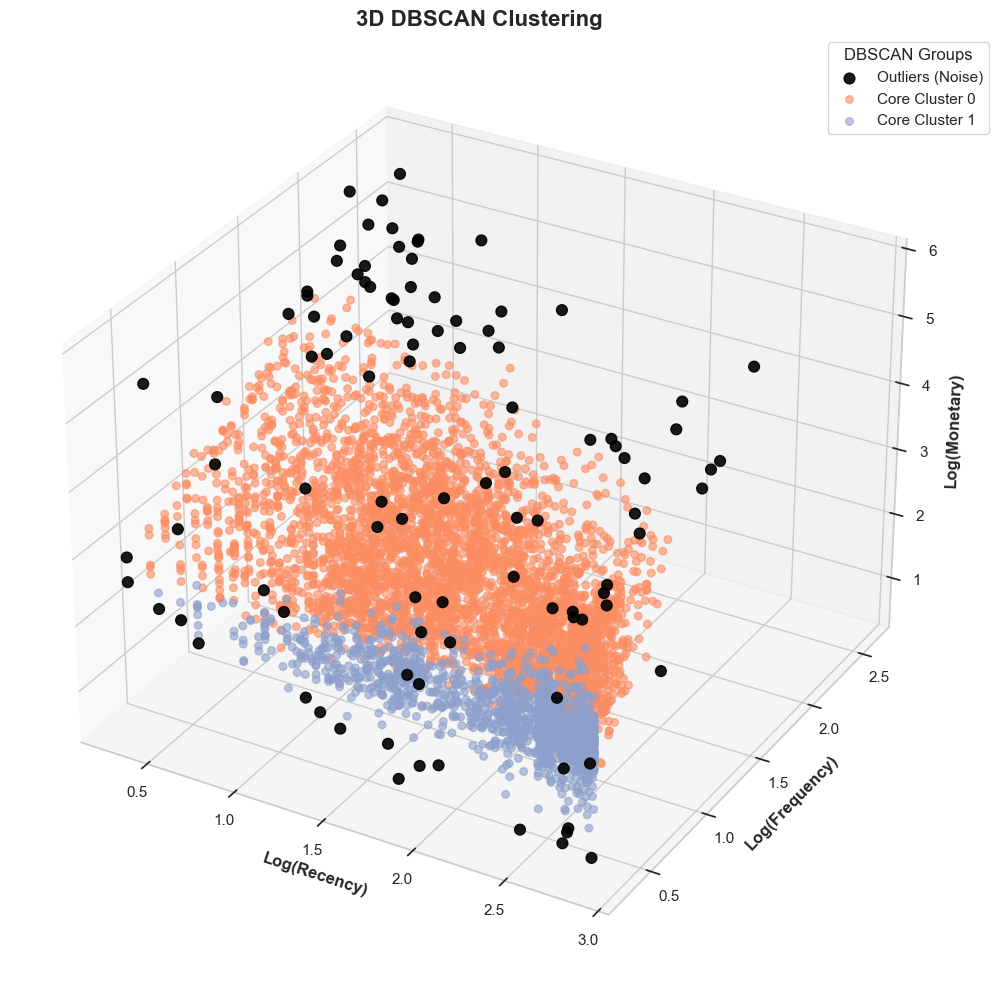

In [26]:
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

unique_clusters = sorted(list(rfm['DBSCAN_Cluster'].unique()))
colors = sns.color_palette("Set2", len(unique_clusters))
color_dict = dict(zip(unique_clusters, colors))
if -1 in color_dict:
    color_dict[-1] = (0.0, 0.0, 0.0) # Black

for cluster in unique_clusters:
    subset = rfm[rfm['DBSCAN_Cluster'] == cluster]
    label_name = 'Outliers (Noise)' if cluster == -1 else f'Core Cluster {cluster}'
    ax.scatter(subset['Log_Recency'], 
               subset['Log_Frequency'], 
               subset['Log_Monetary'], 
               c=[color_dict[cluster]],
               label=label_name, 
               alpha=0.6 if cluster != -1 else 0.9,
               s=30 if cluster != -1 else 60)

ax.set_xlabel('Log(Recency)', fontweight='bold')
ax.set_ylabel('Log(Frequency)', fontweight='bold')
ax.set_zlabel('Log(Monetary)', fontweight='bold')
ax.set_title('3D DBSCAN Clustering', fontsize=16, fontweight='bold')

plt.legend(title='DBSCAN Groups', bbox_to_anchor=(1.05, 1), loc='upper right')
plt.tight_layout()
plt.show()

**Output:**

- 0, 1 : Normal points in clusters
- -1 : ❌ Outlier / Noise (doesn't fit anywhere)

## 4. Cluster Evaluation & Business Interpretation
Let's interpret the **8 K-Means** clusters by looking at the average Recency, Frequency, and Monetary value for each group.

In [27]:
cluster_summary = rfm.groupby('KMeans_Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

cluster_summary.columns = ['Avg Recency (Days)', 'Avg Frequency (Orders)', 'Avg Monetary (£)', 'Customer Count']
cluster_summary = cluster_summary.sort_values(by='Avg Monetary (£)', ascending=False)
display(cluster_summary)

,Avg Recency (Days),Avg Frequency (Orders),Avg Monetary (£),Customer Count
KMeans_Cluster,,,,
3,8.4,39.6,26307.6,308
1,44.9,12.4,5562.5,826
5,241.6,5.9,2416.9,747
4,5.5,6.3,1979.8,385
7,42.1,3.8,1107.4,843
0,353.7,2.3,724.9,1037
6,43.8,1.4,322.9,556
2,454.6,1.1,208.3,1176


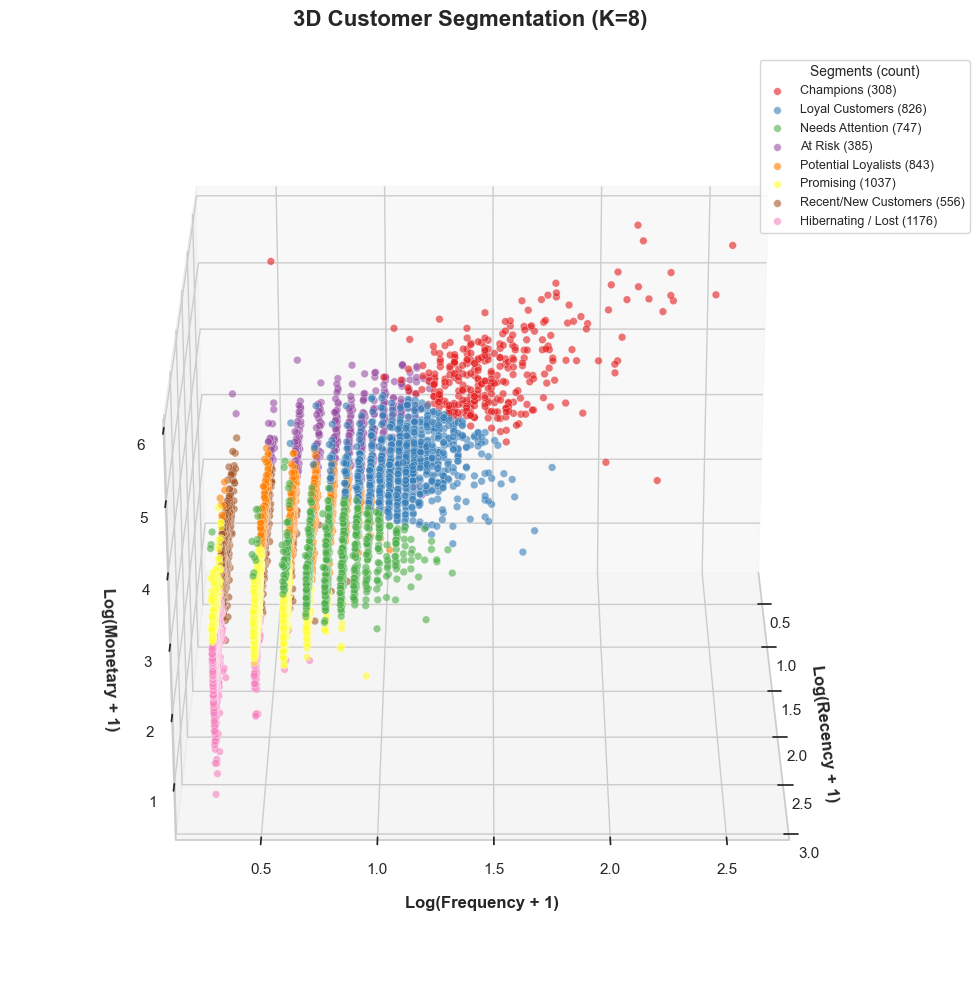

In [28]:
# --- 3D Customer Segmentation ---

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

colors = sns.color_palette("Set1", len(labels))
color_dict = dict(zip(labels, colors))

for segment in labels:
    subset = rfm[rfm['Segment_Name'] == segment]
    ax.scatter(subset['Log_Recency'],
               subset['Log_Frequency'],
               subset['Log_Monetary'],
               c=[color_dict[segment]],
               label=f'{segment} ({len(subset)})',
               alpha=0.6,
               s=30,
               edgecolors='w',
               linewidth=0.3)

ax.set_xlabel('Log(Recency + 1)', fontweight='bold', labelpad=10)
ax.set_ylabel('Log(Frequency + 1)', fontweight='bold', labelpad=10)
ax.set_zlabel('Log(Monetary + 1)', fontweight='bold', labelpad=10)
ax.set_title('3D Customer Segmentation (K=8)', fontsize=16, fontweight='bold', pad=20)

ax.view_init(elev=25, azim=0)

plt.legend(title='Segments (count)', bbox_to_anchor=(1.05, 1), loc='upper right',
           fontsize=9, title_fontsize=10)
plt.tight_layout()
plt.show()


### Who's Who: 8 Customer Segments

| Segment | Recency | Frequency | Spend | One-Liner |
|---------|:-------:|:---------:|:-----:|-----------|
| 🏆 **Champions** | Recent | Often | $$$ | Best customers — love them |
| **Loyal** | A while ago | Often | $$ | Regulars who need a nudge |
| **Potential Loyalists** | Recent | Few times | $$ | About to become regulars |
| 👋 **New Customers** | Very recent | 1–2 times | $ | Just arrived — say hello |
| **Promising** | Recent | Few | $ | Interested but not spending yet |
| ⚠️ **Needs Attention** | Long ago | Often | $$ | Great history, gone quiet |
| 🚨 **At Risk** | Very long ago | Used to be often | Was $$$ | Big spenders who left |
| 💤 **Hibernating** | Longest ago | Rarely | $ | Probably gone — try to wake |

In [29]:
cluster_summary['Segment'] = cluster_summary.index.map(mapping)

In [30]:
cluster_summary

,Avg Recency (Days),Avg Frequency (Orders),Avg Monetary (£),Customer Count,Segment
KMeans_Cluster,,,,,
3,8.4,39.6,26307.6,308,Champions
1,44.9,12.4,5562.5,826,Loyal Customers
5,241.6,5.9,2416.9,747,Needs Attention
4,5.5,6.3,1979.8,385,At Risk
7,42.1,3.8,1107.4,843,Potential Loyalists
0,353.7,2.3,724.9,1037,Promising
6,43.8,1.4,322.9,556,Recent/New Customers
2,454.6,1.1,208.3,1176,Hibernating / Lost


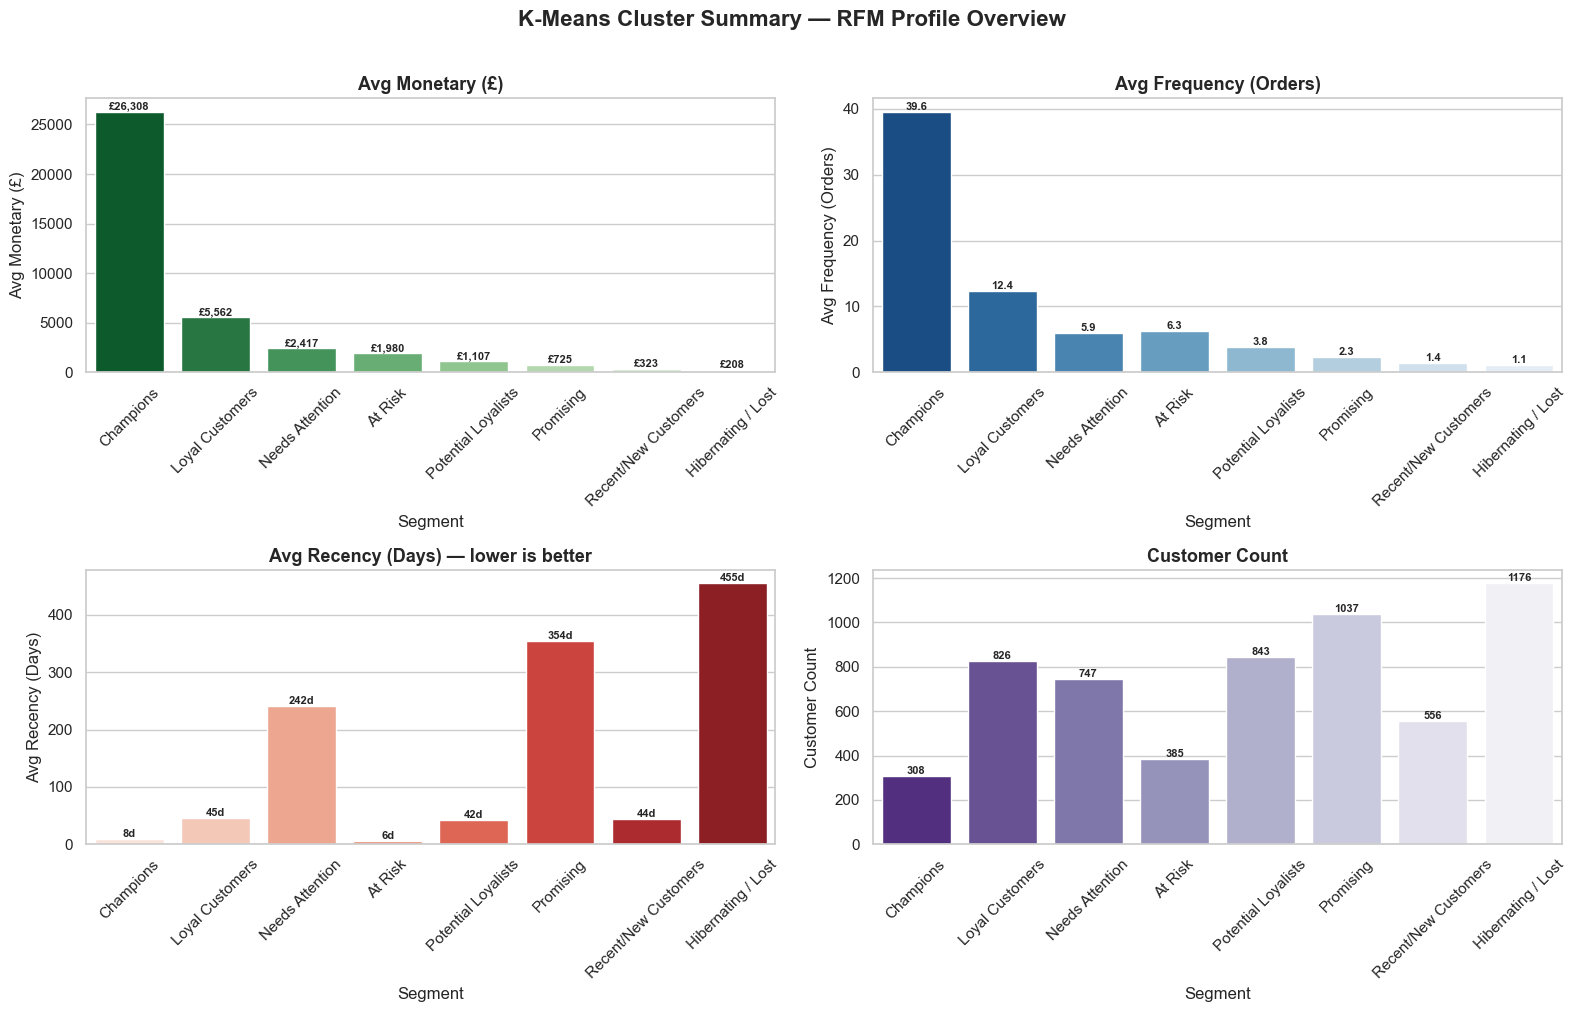

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Avg Monetary
sns.barplot(data=cluster_summary, x='Segment', y='Avg Monetary (£)',
            palette='Greens_r', ax=axes[0, 0])
axes[0, 0].set_title('Avg Monetary (£)', fontsize=13, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'£{p.get_height():,.0f}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=8, fontweight='bold')

# Avg Frequency
sns.barplot(data=cluster_summary, x='Segment', y='Avg Frequency (Orders)',
            palette='Blues_r', ax=axes[0, 1])
axes[0, 1].set_title('Avg Frequency (Orders)', fontsize=13, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f'{p.get_height():.1f}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=8, fontweight='bold')

# Avg Recency
sns.barplot(data=cluster_summary, x='Segment', y='Avg Recency (Days)',
            palette='Reds', ax=axes[1, 0])
axes[1, 0].set_title('Avg Recency (Days) — lower is better', fontsize=13, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f'{p.get_height():.0f}d',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=8, fontweight='bold')

# Customer Count
sns.barplot(data=cluster_summary, x='Segment', y='Customer Count',
            palette='Purples_r', ax=axes[1, 1])
axes[1, 1].set_title('Customer Count', fontsize=13, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f'{int(p.get_height())}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=8, fontweight='bold')

fig.suptitle('K-Means Cluster Summary — RFM Profile Overview', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


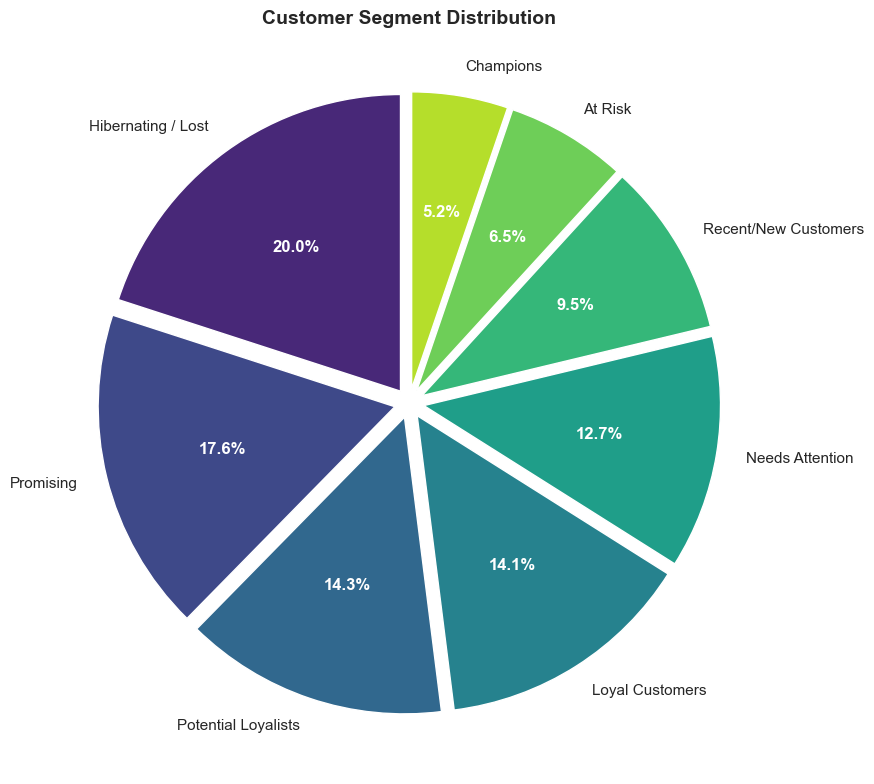

In [32]:
# --- Customer Segment Distribution ---
segment_counts = rfm['Segment_Name'].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))
colors_pie = sns.color_palette('viridis', n_colors=optimal_k)

wedges, texts, autotexts = ax.pie(segment_counts.values,
                                   labels=segment_counts.index,
                                   colors=colors_pie,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   explode=[0.05] * len(segment_counts))
ax.set_title('Customer Segment Distribution', fontsize=14, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
plt.tight_layout()
plt.show()


## 5. Key Takeaways

- **K-Means (K=8)** successfully segmented customers into 8 actionable groups — from Champions to Hibernating.
- **Business needs outweighed pure math**: The elbow method favored K=4, but 8 segments enable targeted marketing impossible with broader groups.
- **DBSCAN identified 2 core clusters + noise**: Confirms customer behavior is a spectrum — K-Means is the better tool here.
- **Segment sizes are well-balanced**: No single segment dominates, making targeted campaigns viable across all groups.
- **Champions and Loyal Customers** drive the most revenue — nurture them. **At Risk and Hibernating** need re-engagement campaigns.

## 6. MLFlow Tracking

In [33]:
mlflow_dir = pathlib.Path.cwd().parent / 'mlruns'
mlflow.set_tracking_uri(f"file:///{mlflow_dir}")

mlflow.set_experiment("Customer_Segmentation")

with mlflow.start_run():
    mlflow.log_param("optimal_k", optimal_k)
    mlflow.log_param("dbscan_eps", 0.5)
    mlflow.log_param("dbscan_min_samples", 15)
    mlflow.log_metric("silhouette_score_kmeans", sil_score)
    mlflow.log_metric("num_dbscan_clusters", n_clusters)
    mlflow.log_metric("dbscan_noise_points", n_noise)

2026/04/26 22:30:03 INFO mlflow.tracking.fluent: Experiment with name 'Customer_Segmentation' does not exist. Creating a new experiment.


## 7. Save Segmented Data

In [34]:
rfm.drop(columns=['Log_Recency', 'Log_Frequency', 'Log_Monetary'], inplace=True, errors='ignore')

rfm.to_csv('../data/processed/customer_segments.csv')
print("Segmented data saved to ../data/processed/customer_segments.csv")

Segmented data saved to ../data/processed/customer_segments.csv
